In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
# Cell 2 — Load Titanic dataset
df = sns.load_dataset('titanic')

print("Dataset loaded ✅")
print(f"Shape: {df.shape}")   # rows x columns

Dataset loaded ✅
Shape: (891, 15)


In [4]:
# Cell 3 — See first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Cell 4 — See last 5 rows
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [6]:
# Cell 5 — Dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [7]:
# Cell 6 — Statistical summary
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Cell 7 — Read the results intelligently
print("=== What df.describe() tells us ===")
print(f"\nAverage age:    {df['age'].mean():.1f} years")
print(f"Median age:     {df['age'].median():.1f} years")
print(f"Oldest person:  {df['age'].max():.0f} years")
print(f"Youngest:       {df['age'].min():.1f} years")
print(f"Std deviation:  {df['age'].std():.1f} years")
print(f"Skewness:       {df['age'].skew():.2f}")
print(f"Kurtosis:       {df['age'].kurtosis():.2f}")

=== What df.describe() tells us ===

Average age:    29.7 years
Median age:     28.0 years
Oldest person:  80 years
Youngest:       0.4 years
Std deviation:  14.5 years
Skewness:       0.39
Kurtosis:       0.18


In [9]:
# Cell 8 — Find all missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])


             Missing Count  Missing %
age                    177       19.9
embarked                 2        0.2
deck                   688       77.2
embark_town              2        0.2


In [10]:
# Cell 9 — Survival rate overall
survival_rate = df['survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Survival by gender
print("\nSurvival rate by gender:")
print(df.groupby('sex')['survived'].mean() * 100)

# Survival by class
print("\nSurvival rate by class:")
print(df.groupby('pclass')['survived'].mean() * 100)

Overall survival rate: 38.4%

Survival rate by gender:
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

Survival rate by class:
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


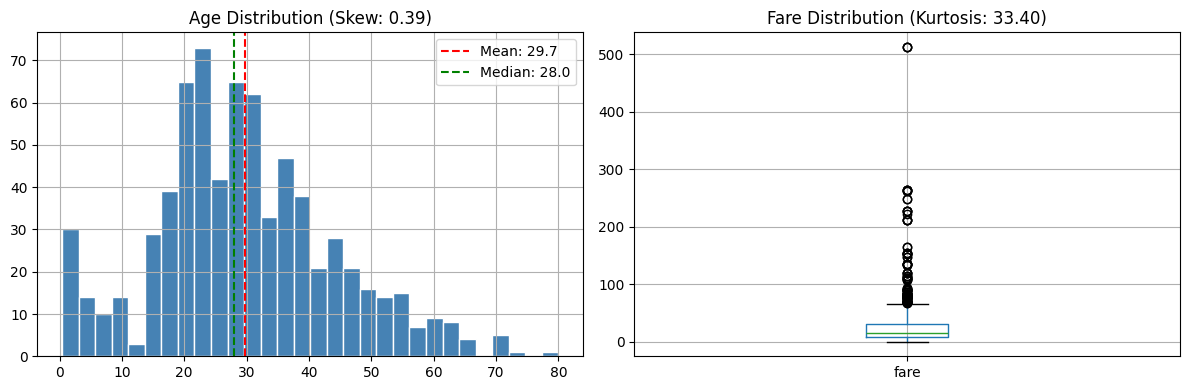

In [11]:
# Cell 10 — Age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with skewness
df['age'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['age'].mean(),   color='red',   linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
axes[0].axvline(df['age'].median(), color='green', linestyle='--', label=f"Median: {df['age'].median():.1f}")
axes[0].set_title(f"Age Distribution (Skew: {df['age'].skew():.2f})")
axes[0].legend()

# Fare boxplot — spot outliers
df.boxplot(column='fare', ax=axes[1])
axes[1].set_title(f"Fare Distribution (Kurtosis: {df['fare'].kurtosis():.2f})")

plt.tight_layout()
plt.show()

In [12]:
# Cell 4 — isnull()

# Total missing per column
print(df.isnull().sum())

print("---")

# Missing as percentage
print((df.isnull().sum() / len(df) * 100).round(1))

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
---
survived        0.0
pclass          0.0
sex             0.0
age            19.9
sibsp           0.0
parch           0.0
fare            0.0
embarked        0.2
class           0.0
who             0.0
adult_male      0.0
deck           77.2
embark_town     0.2
alive           0.0
alone           0.0
dtype: float64


In [13]:
# Cell 5 — value_counts()

# How many male vs female?
print(df['sex'].value_counts())

print("---")

# As percentages
print(df['sex'].value_counts(normalize=True) * 100)

print("---")

# Passenger class distribution
print(df['pclass'].value_counts().sort_index())

sex
male      577
female    314
Name: count, dtype: int64
---
sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64
---
pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [14]:
# Cell 6 — dropna()

print(f"Before: {df.shape}")         # 891 rows

df_clean = df.dropna(subset=['age']) # only drop rows where age is missing

print(f"After:  {df_clean.shape}")   # 714 rows

Before: (891, 15)
After:  (714, 15)


In [16]:
# Cell 7 — fillna()

# Fill age with MEDIAN (use median because age can be skewed)
df['age'] = df['age'].fillna(df['age'].median())

# Fill embarked with MODE (most common value — for text columns)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Check — should now show 0 missing for age and embarked
print(df[['age', 'embarked']].isnull().sum())

age         0
embarked    0
dtype: int64


In [17]:
# Cell 8 — drop column with too many missing values

print(f"Deck missing: {df['deck'].isnull().sum()}")  # 688 out of 891!

df = df.drop(columns=['deck'])  # too many missing — just remove it

print(df.shape)  # one less column now

Deck missing: 688
(891, 14)


In [20]:
# Cell 8 — drop column safely
print("Columns available:", df.columns.tolist())

# Only drop deck if it exists
if 'deck' in df.columns:
    df = df.drop(columns=['deck'])
    print("Deck column dropped ✅")
else:
    print("Deck column already gone ✅")

print(f"Shape now: {df.shape}")

Columns available: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
Deck column already gone ✅
Shape now: (891, 14)


In [21]:
# Cell 9 — Check columns and missing values
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [22]:
# Cell 10 — Feature 1: family_size
# sibsp = siblings/spouses, parch = parents/children
df['family_size'] = df['sibsp'] + df['parch'] + 1

print(df[['sibsp', 'parch', 'family_size']].head(10))

   sibsp  parch  family_size
0      1      0            2
1      1      0            2
2      0      0            1
3      1      0            2
4      0      0            1
5      0      0            1
6      0      0            1
7      3      1            5
8      0      2            3
9      1      0            2


In [23]:
# Cell 11 — Feature 2: age_group
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 12, 18, 35, 60, 100],
                          labels=['child', 'teen', 'young_adult', 'adult', 'senior'])

print(df['age_group'].value_counts())

age_group
young_adult    535
adult          195
teen            70
child           69
senior          22
Name: count, dtype: int64


In [24]:
# Cell 12 — Feature 3: fare_group (split fare into cheap/mid/expensive)
df['fare_group'] = pd.cut(df['fare'],
                           bins=[0, 10, 50, 600],
                           labels=['cheap', 'mid', 'expensive'])

print(df['fare_group'].value_counts())

fare_group
mid          395
cheap        321
expensive    160
Name: count, dtype: int64


In [25]:
# Cell 13 — See all your new features together
print(df[['age', 'age_group', 'fare', 'fare_group', 
          'sibsp', 'parch', 'family_size']].head(10))

print(f"\nDataset now has {df.shape[1]} columns")

    age    age_group     fare fare_group  sibsp  parch  family_size
0  22.0  young_adult   7.2500      cheap      1      0            2
1  38.0        adult  71.2833  expensive      1      0            2
2  26.0  young_adult   7.9250      cheap      0      0            1
3  35.0  young_adult  53.1000  expensive      1      0            2
4  35.0  young_adult   8.0500      cheap      0      0            1
5  28.0  young_adult   8.4583      cheap      0      0            1
6  54.0        adult  51.8625  expensive      0      0            1
7   2.0        child  21.0750        mid      3      1            5
8  27.0  young_adult  11.1333        mid      0      2            3
9  14.0         teen  30.0708        mid      1      0            2

Dataset now has 17 columns


In [26]:
# Cell 14 — Final df.describe() on everything
df.describe()

,survived,pclass,age,sibsp,parch,fare,family_size
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [27]:
# Read fare skewness
print(f"Fare skewness:  {df['fare'].skew():.2f}")
print(f"Age skewness:   {df['age'].skew():.2f}")

print(f"\nSurvival rate:  {df['survived'].mean()*100:.1f}%")

print(f"\nFare mean:      ${df['fare'].mean():.2f}")
print(f"Fare median:    ${df['fare'].median():.2f}")
print(f"Fare max:       ${df['fare'].max():.2f}")

Fare skewness:  4.79
Age skewness:   0.51

Survival rate:  38.4%

Fare mean:      $32.20
Fare median:    $14.45
Fare max:       $512.33


In [28]:
# Feature 2: fare_per_person
# How much did each person ACTUALLY pay per family member?
df['fare_per_person'] = df['fare'] / df['family_size']

print(df[['fare', 'family_size', 'fare_per_person']].head(10))
print(f"\nAverage fare per person: ${df['fare_per_person'].mean():.2f}")
print(f"Median fare per person:  ${df['fare_per_person'].median():.2f}")

      fare  family_size  fare_per_person
0   7.2500            2          3.62500
1  71.2833            2         35.64165
2   7.9250            1          7.92500
3  53.1000            2         26.55000
4   8.0500            1          8.05000
5   8.4583            1          8.45830
6  51.8625            1         51.86250
7  21.0750            5          4.21500
8  11.1333            3          3.71110
9  30.0708            2         15.03540

Average fare per person: $19.92
Median fare per person:  $8.30


In [29]:
# Feature 3: is_child
# Children may have had priority in lifeboats
df['is_child'] = (df['age'] < 12).astype(int)

# 1 = child, 0 = adult
print(df['is_child'].value_counts())

print(f"\nChild survival rate:  {df[df['is_child']==1]['survived'].mean()*100:.1f}%")
print(f"Adult survival rate:  {df[df['is_child']==0]['survived'].mean()*100:.1f}%")

is_child
0    823
1     68
Name: count, dtype: int64

Child survival rate:  57.4%
Adult survival rate:  36.8%


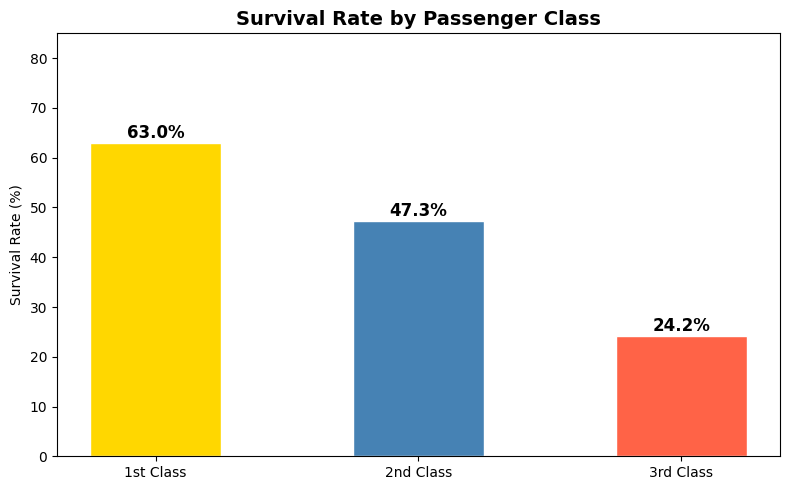

In [30]:
# Visualization 1 — Survival rate by class
import matplotlib.pyplot as plt

survival_by_class = df.groupby('pclass')['survived'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(['1st Class', '2nd Class', '3rd Class'], 
                survival_by_class,
                color=['gold', 'steelblue', 'tomato'],
                edgecolor='white', width=0.5)

for bar, val in zip(bars, survival_by_class):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1,
             f'{val:.1f}%', 
             ha='center', fontweight='bold', fontsize=12)

plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 85)
plt.tight_layout()
plt.show()

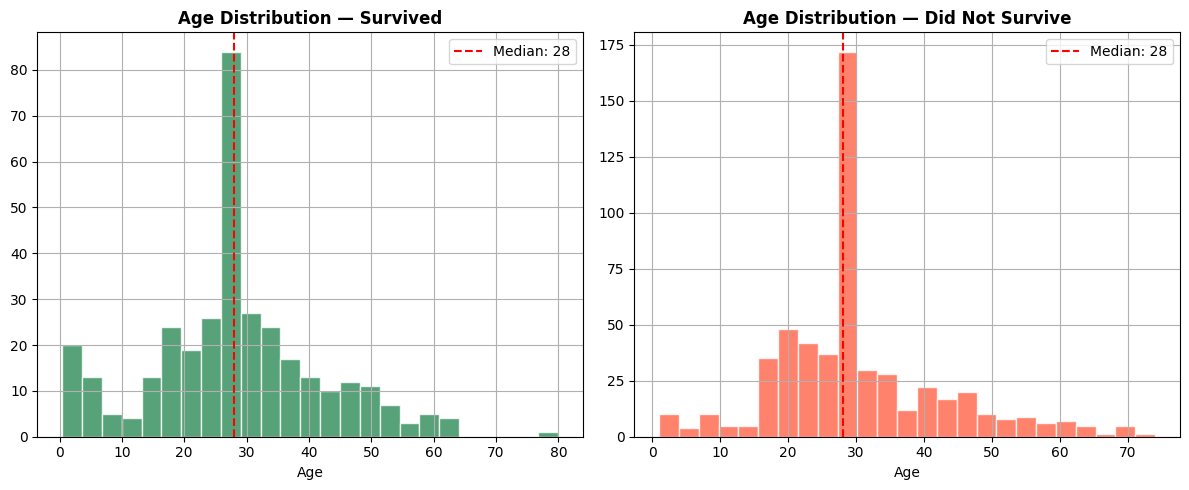

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df[df['survived']==1]['age'].hist(bins=25, ax=axes[0], 
                                   color='seagreen', 
                                   edgecolor='white', alpha=0.8)
axes[0].axvline(df[df['survived']==1]['age'].median(), 
                color='red', linestyle='--', 
                label=f"Median: {df[df['survived']==1]['age'].median():.0f}")
axes[0].set_title('Age Distribution — Survived', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()

df[df['survived']==0]['age'].hist(bins=25, ax=axes[1], 
                                   color='tomato', 
                                   edgecolor='white', alpha=0.8)
axes[1].axvline(df[df['survived']==0]['age'].median(), 
                color='red', linestyle='--',
                label=f"Median: {df[df['survived']==0]['age'].median():.0f}")
axes[1].set_title('Age Distribution — Did Not Survive', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.show()

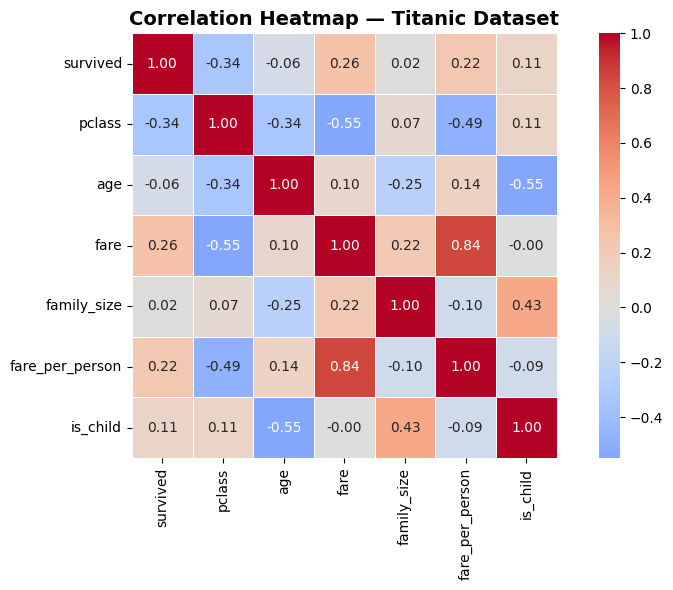

In [32]:
import seaborn as sns

numeric_cols = ['survived', 'pclass', 'age', 'fare', 
                'family_size', 'fare_per_person', 'is_child']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — Titanic Dataset', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()